<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-22</br>
</div>

</br>

In [2]:
# TODO 0: 라이브러리 임포트 및 디바이스 설정


import torch
import matplotlib.pyplot as plt

# 디바이스 자동 감지 (CUDA > MPS > CPU)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"사용 디바이스: {device}")

# matplotlib 한글 폰트 설정
import platform
if platform.system() == "Darwin":  # macOS
    plt.rc("font", family="AppleGothic")
elif platform.system() == "Windows":
    plt.rc("font", family="Malgun Gothic")
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

사용 디바이스: cuda


</br>

# 학습 내용
>이번 장에서는 <strong>텍스트-투-이미지 생성(Text-to-Image Generation)</strong>에 대해 학습합니다.</br></br>
>Diffusion 모델의 원리와 Stable Diffusion 파이프라인을 활용한 이미지 생성을 학습해봅시다.

<div style="text-align:center">

</div>

</br>

# Diffusion 모델 (Diffusion Model)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">노이즈를 점진적으로 제거</mark>하여 이미지를 생성하는 생성 모델입니다.

> 텍스트-투-이미지 생성은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">디자인 프로토타이핑, 창작, 광고 소재 제작</mark> 등에서 전문 디자인 도구 없이도 아이디어를 즉시 시각화할 수 있게 합니다.</br></br>
> Diffusion 모델의 핵심 아이디어는 먼저 원본 이미지에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가우시안 노이즈를 단계적으로 추가(Forward Process)</mark>하여 순수 노이즈 상태로 만든 뒤, 이 과정을 역으로 학습하는 것입니다.</br></br>
> 학습 후에는 순수 노이즈에서 출발해 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">노이즈를 단계적으로 제거(Reverse Process)</mark>하며 이미지를 생성하고, 텍스트 프롬프트는 CLIP 텍스트 인코더를 통해 이 디노이징 과정을 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">원하는 방향으로 안내</mark>합니다.</br>

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">과정</th>
      <th>설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">Forward (노이즈 추가)</td><td>원본 이미지에 점진적으로 노이즈 추가</td></tr>
    <tr><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Reverse (디노이징)</mark></td><td>노이즈에서 이미지를 복원하도록 학습</td></tr>
  </tbody>
</table>

<div style="text-align:center">

</div>

</br>

## Stable Diffusion Pipeline
> Hugging Face `diffusers` 라이브러리로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">텍스트 프롬프트에서 이미지를 생성</mark>합니다.

In [3]:
# TODO 1: Stable Diffusion 파이프라인을 사전학습 모델로부터 로드해봅시다.
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to(device)

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [4]:
# TODO 2: 고양이가 창턱에 앉아 있는 석양 장면을 프롬프트로 지정하여 이미지를 생성해봅시다.
#         프롬프트: a photo of a cat sitting on a windowsill, sunset
image = pipe(
    prompt="a photo of a cat sitting on a windowsill, sunset",
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

💡생성 결과
> GPU 환경에서 실행하면 석양을 배경으로 창턱에 앉아 있는 고양이 사진 스타일의 이미지가 생성됩니다.</br>
> Stable Diffusion 기본 해상도인 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">512x512</mark> 크기로 출력됩니다.

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">파라미터</th>
      <th>설명</th>
      <th style="text-align:center">권장값</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>prompt</code></td><td>생성할 이미지 설명</td><td style="text-align:center">구체적으로</td></tr>
    <tr><td style="text-align:center"><code>num_inference_steps</code></td><td>디노이징 단계 수</td><td style="text-align:center">30~50</td></tr>
    <tr><td style="text-align:center"><code>guidance_scale</code></td><td><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">프롬프트 충실도</mark></td><td style="text-align:center">7.0~8.5</td></tr>
    <tr><td style="text-align:center"><code>negative_prompt</code></td><td>제외할 요소</td><td style="text-align:center">선택사항</td></tr>
    <tr><td style="text-align:center"><code>seed</code></td><td>재현성을 위한 시드</td><td style="text-align:center">정수</td></tr>
  </tbody>
</table>

💡guidance_scale 이해
> 낮은 값(1~3): 다양하지만 프롬프트 무시 경향</br>
> 높은 값(10+): 프롬프트에 충실하지만 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">과포화/아티팩트</mark> 발생</br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">7.5</mark> 전후가 일반적으로 좋은 균형점입니다.

</br>

## 프롬프트 작성 팁

  0%|          | 0/50 [00:00<?, ?it/s]

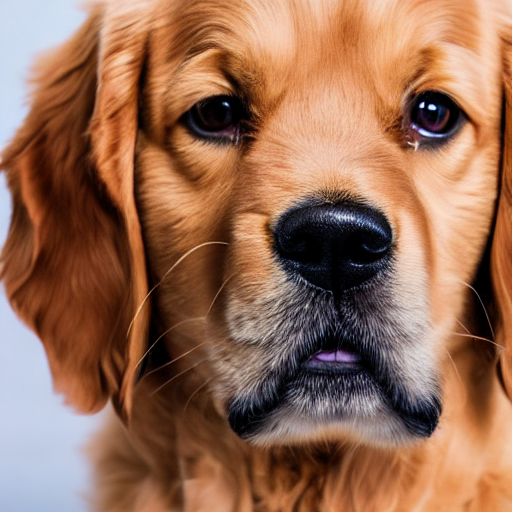

In [5]:
# TODO 3: 주제, 스타일, 조명, 품질 키워드를 포함한 상세 프롬프트와 제외할 요소를 지정하는 네거티브 프롬프트를 활용하여 고품질 이미지를 생성해봅시다.
#         프롬프트: a golden retriever puppy, studio photography, soft lighting, 4k, detailed
#         부정 프롬프트: blurry, low quality, distorted
prompt = "a golden retriever puppy, studio photography, soft lighting, 4k, detailed"
negative = "blurry, low quality, distorted"

image = pipe(prompt=prompt, negative_prompt=negative).images[0]
image

💡생성 결과
> 스튜디오 조명 아래 골든 리트리버 강아지 사진이 생성됩니다.</br>
> `negative_prompt`로 "blurry, low quality"를 지정하여 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">선명하고 고품질</mark>의 이미지가 출력됩니다.

💡SanaPipeline vs StableDiffusionPipeline
> SanaPipeline은 경량화된 모델로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">빠른 생성</mark>에 적합합니다.</br>
> Stable Diffusion은 더 높은 품질이지만 GPU 메모리를 많이 사용합니다.

</br>

## 시드 제어 (Seed Control)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">동일한 시드 = 동일한 노이즈 = 동일한 이미지</mark>를 생성합니다.
> `torch.Generator`로 초기 노이즈를 고정하면, 같은 프롬프트에서 재현 가능한 결과를 얻을 수 있습니다.

  0%|          | 0/50 [00:00<?, ?it/s]

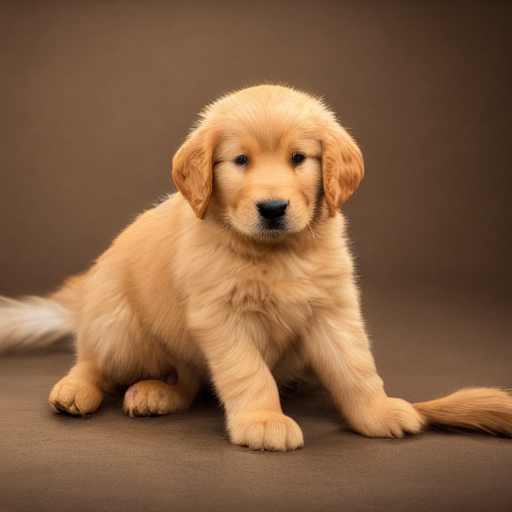

In [8]:
# TODO 4: 시드를 지정하여 재현 가능한 이미지를 생성해봅시다.

# MPS에서는 Generator를 "cpu"에 생성해야 합니다.
generator_device = 'cpu' if device == 'mps' else device
generator_a = torch.Generator(device=generator_device).manual_seed(42)
image_seed_42 = pipe(prompt=prompt, generator=generator_a).images[0]
image_seed_42

  0%|          | 0/50 [00:00<?, ?it/s]

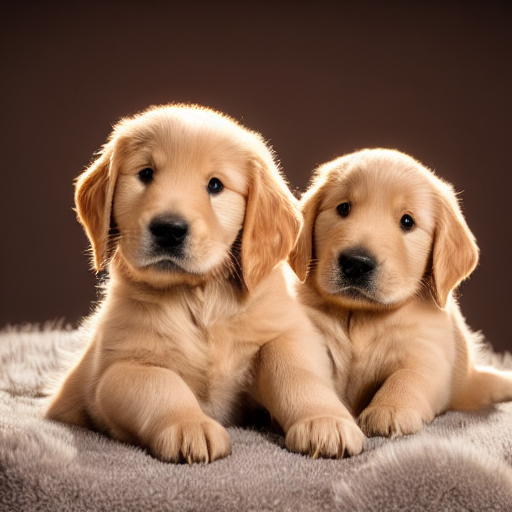

In [9]:
# TODO 5: 다른 시드로 생성하여 결과가 달라지는지 확인해봅시다.
generator_b = torch.Generator(device=generator_device).manual_seed(777)
image_seed_777 = pipe(prompt=prompt, generator=generator_b).images[0]
image_seed_777

/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1440/814384264.py:13: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

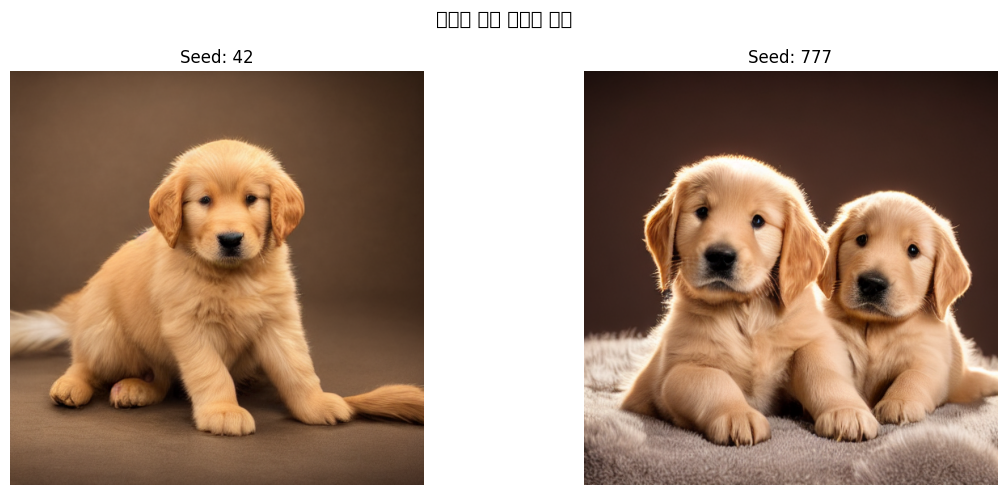

In [10]:
# TODO 6: 두 이미지를 나란히 비교해봅시다.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_seed_42)
axes[0].set_title("Seed: 42")
axes[0].axis("off")
axes[1].imshow(image_seed_777)
axes[1].set_title("Seed: 777")
axes[1].axis("off")
plt.suptitle("시드에 따른 이미지 변화", fontsize=14)
plt.tight_layout()
plt.show()

💡시드와 다양성
> 같은 시드를 사용하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">실험의 재현성</mark>을 보장합니다.</br>
> 다양한 이미지가 필요하면 시드를 변경하거나, 여러 시드를 반복 생성하여 최적의 결과를 선택합니다.

In [8]:
# TODO 7: 생성한 이미지를 저장해봅시다. (다음 실습에서 사용합니다)
image_seed_42.save("dog.jpg")
